In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

---

In [44]:
df = pd.read_csv(
    "/Users/cooper/Desktop/CAMELS-CH/clustering_results/cluster_assignments12.csv"
)

df["country"] = df["gauge_id"].str.split('_').str[0]

cluster_country_counts = df.groupby(["cluster", "country"]).size().unstack(fill_value=0)

print(cluster_country_counts)

country  CH   CL  USA
cluster              
0        49  114    3
1         2    4  139
2        22    4  122
3         0   23   96
4         0    2   44
5         0   45    0
6         1    4   23
7         0    2   30
8        11    0   87
9        40    2   53
10        3   33   13
11        7    0   52


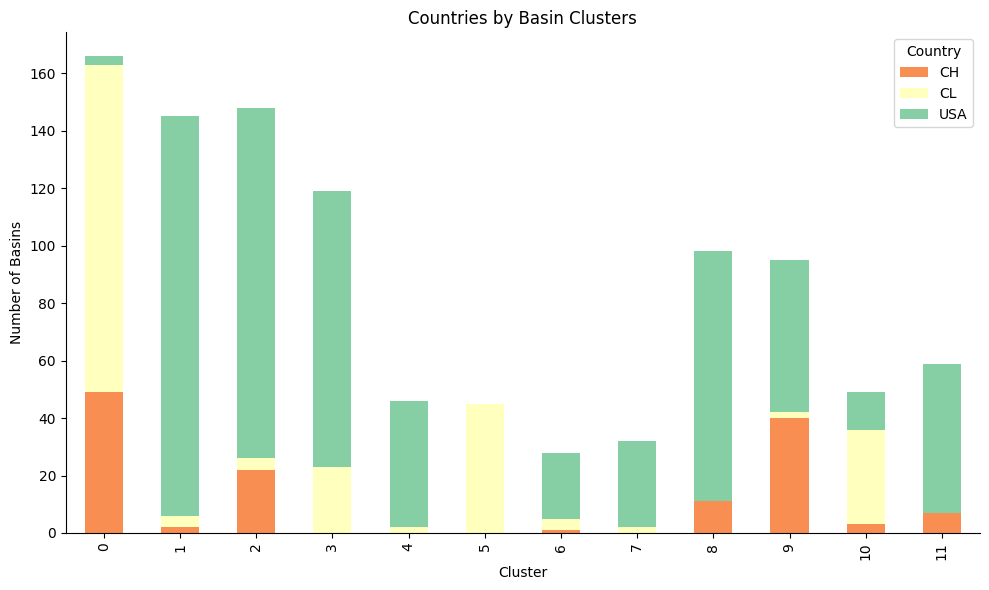

In [45]:
plt.figure(figsize=(10, 6))

palette = sns.color_palette("Spectral", len(cluster_country_counts.columns))

cluster_country_counts.plot(kind='bar', stacked=True, color=palette, ax=plt.gca())
plt.title('Countries by Basin Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of Basins')
plt.legend(title='Country')
plt.tight_layout()

sns.despine()
plt.show()

In [46]:
cluster_sizes = df['cluster'].value_counts().sort_index()

# Print key statistics
print("Cluster Sizes:")
print(cluster_sizes)
print("\nBiggest Cluster:")
print(cluster_sizes.idxmax(), "with", cluster_sizes.max(), "basins")
print("\nSmallest Cluster:")
print(cluster_sizes.idxmin(), "with", cluster_sizes.min(), "basins")

Cluster Sizes:
cluster
0     166
1     145
2     148
3     119
4      46
5      45
6      28
7      32
8      98
9      95
10     49
11     59
Name: count, dtype: int64

Biggest Cluster:
0 with 166 basins

Smallest Cluster:
6 with 28 basins


In [50]:
for country in df["country"].unique():
    path_to_basins = f"/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/{country}/post_processed/shapefiles/{country}/{country}_basin_shapes.shp"

    basins = gpd.read_file(path_to_basins)

    basins = basins.merge(
        df[["gauge_id", "cluster"]],
        left_on="gauge_id",
        right_on="gauge_id",
        how="inner",
    )

    # print(basins.head())

    # Save the merged GeoDataFrame to a new shapefile
    output_path = f"/Users/cooper/Desktop/CAMELS-CH/clustering_results/basins/clustered_basins_12_{country}.shp"\
    
    basins.to_file(output_path, driver='ESRI Shapefile')
    print(f"Saved clustered basins for {country} to {output_path}")

Saved clustered basins for CH to /Users/cooper/Desktop/CAMELS-CH/clustering_results/basins/clustered_basins_12_CH.shp
Saved clustered basins for CL to /Users/cooper/Desktop/CAMELS-CH/clustering_results/basins/clustered_basins_12_CL.shp
Saved clustered basins for USA to /Users/cooper/Desktop/CAMELS-CH/clustering_results/basins/clustered_basins_12_USA.shp


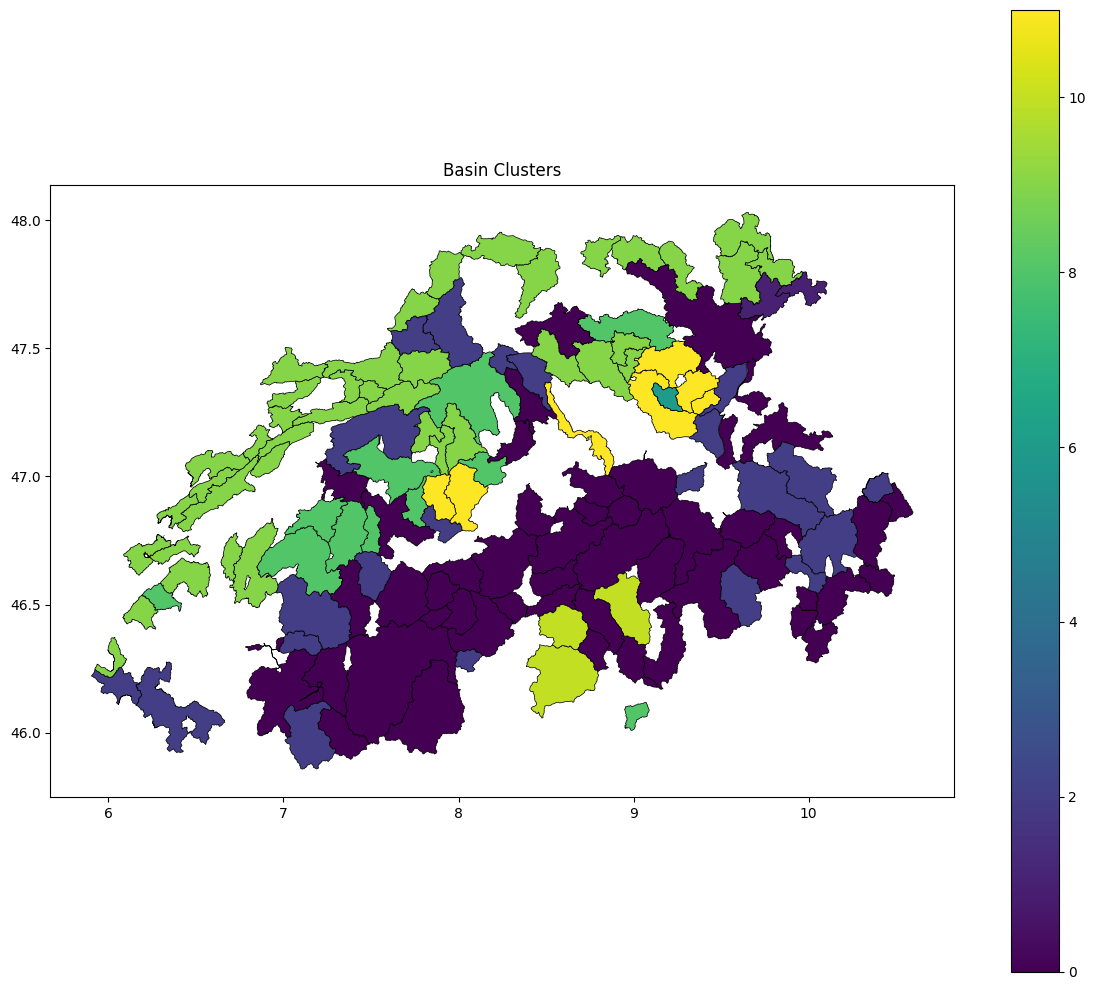

cluster
0     49
9     40
2     22
8     11
11     7
10     3
1      2
6      1
Name: count, dtype: int64


In [41]:
# Plot basins colored by cluster
fig, ax = plt.subplots(figsize=(12, 10))
basins.plot(column='cluster', 
            ax=ax, 
            legend=True, 
            cmap='viridis', 
            edgecolor='black', 
            linewidth=0.5)

plt.title('Basin Clusters')
plt.tight_layout()
plt.show()

# Optional: Print number of basins per cluster
print(basins['cluster'].value_counts())